<a href="https://colab.research.google.com/github/prakhar-2408/Flexe-Glove-EClub/blob/main/Week_4/Sign_Language/MNIST_trial/MNIST_CNN_test%20240763.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd
import os # For checking file existence and paths

In [ ]:
# load dataset
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

In [ ]:
from sklearn.model_selection import train_test_split
# splitting dataset to get label and pixel data
train_data_labels = train_data['label']
train_data_pixels = train_data.drop(columns='label')

train_images, test_images, train_labels, test_labels = train_test_split(
    train_data_pixels, train_data_labels, test_size=0.2)

# reshaping
train_images = train_images.values.reshape(-1, 28, 28, 1)
test_images = test_images.values.reshape((-1, 28, 28, 1))

In [ ]:
# normalizing
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [ ]:
# one hot encoding data labels
train_labels_one_hot = keras.utils.to_categorical(train_labels, 10)
test_labels_one_hot = keras.utils.to_categorical(test_labels, 10)

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))) # adding a layer to get 32 features
model.add(layers.MaxPooling2D((2, 2))) # reducing dimension
model.add(layers.Flatten()) # convert previous 2D data to 1D
model.add(layers.Dense(128, activation='relu')) # dense layer to connect to all previous neuron and get 128 nodes
model.add(layers.Dense(10, activation='softmax')) # finally getting 10 nodes

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compiling model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_labels_one_hot, epochs=1, batch_size=128, validation_data=(test_images, test_labels_one_hot))

263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.9625 - loss: 0.1344 - val_accuracy: 0.9707 - val_loss: 0.0987


263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


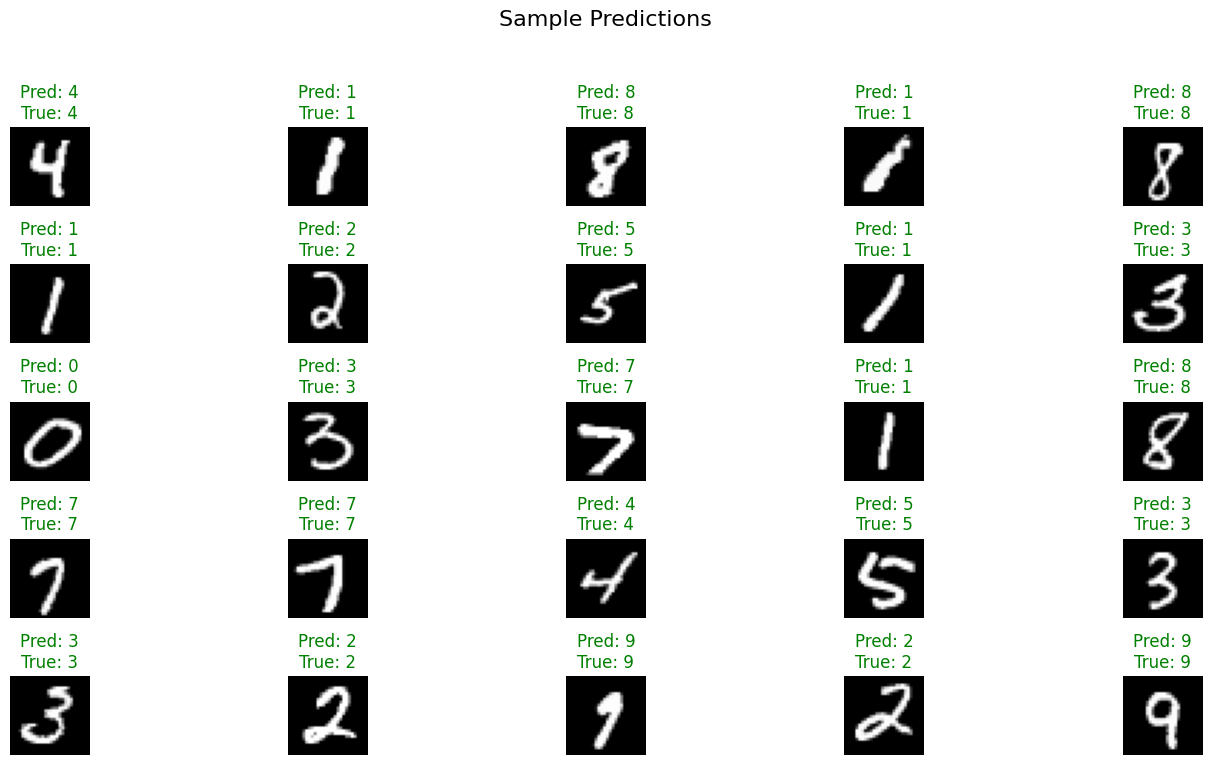

In [ ]:
predictions = model.predict(test_images) # getting predictions
predicted_labels = np.argmax(predictions, axis=1) # converting back to labels
true_labels = np.argmax(test_labels_one_hot, axis=1)

plt.figure(figsize=(15, 8))
for i in range(25):
    idx = np.random.randint(0, len(test_images)) # Pick a random index
    plt.subplot(5, 5, i + 1)
    plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')
    color = "green" if predicted_labels[idx] == true_labels[idx] else "red"
    plt.title(f"Pred: {predicted_labels[idx]}\nTrue: {true_labels[idx]}", color=color)
    plt.axis('off')
plt.suptitle("Sample Predictions", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()